# full 2023ixf reduction (STIS UV-optical + COS NUV)

end-to-end on one epoch of SN2023ixf. our own extraction for all three STIS ccd
gratings (g230lb + g430l + g750l, prop 17205 oezt01 visit), g750l defringed with the
contemporaneous ccdflat (oezt010d0), then coadded together with the COS NUV g230l
spectrum (lf8803, already reduced in cos_sandbox) onto one common wavelength axis.

reduction itself runs in wsl (surf_uv env) since ocrreject/x1d/defringe need the
hstcal binaries; this notebook does the download, fires the wsl steps, then loads the
resulting x1d files and builds the coadd.

In [5]:
import warnings
warnings.filterwarnings('ignore')
import os, subprocess
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from astropy.io import fits
import astropy.units as u
from astroquery.mast import Observations
try:
    from specutils import Spectrum as Spec1D
except ImportError:
    from specutils import Spectrum1D as Spec1D
from specutils.manipulation import FluxConservingResampler

In [6]:
# one stis epoch of 2023ixf with all 3 ccd gratings, plus the g750l fringe flat
# oezt01040 g230lb (769s), oezt010h0 g430l (574s), oezt010e0 g750l (492s), oezt010d0 ccdflat
roots = ['oezt01040', 'oezt010h0', 'oezt010e0', 'oezt010d0']
pl = Observations.get_product_list(Observations.query_criteria(obs_id=roots))
# flt for ocrreject, crj+wav for defringe/x1d, raw for the fringe flat, sx1 as a cross-check
keep = [f.endswith(('_flt.fits', '_crj.fits', '_wav.fits', '_raw.fits', '_sx1.fits'))
        for f in pl['productFilename']]
Observations.download_products(pl[keep], download_dir='../data/2023ixf', mrp_only=False)

INFO: Found cached file ../data/2023ixf\mastDownload\HST\oezt010e0\oezt010e0_wav.fits with expected size 2260800. [astroquery.query]
INFO: Found cached file ../data/2023ixf\mastDownload\HST\oezt010e0\oezt010e0_raw.fits with expected size 2260800. [astroquery.query]
INFO: Found cached file ../data/2023ixf\mastDownload\HST\oezt010e0\oezt010e0_flt.fits with expected size 10537920. [astroquery.query]
INFO: Found cached file ../data/2023ixf\mastDownload\HST\oezt010d0\oezt010d0_raw.fits with expected size 4501440. [astroquery.query]
INFO: Found cached file ../data/2023ixf\mastDownload\HST\oezt010d0\oezt010d0_flt.fits with expected size 21049920. [astroquery.query]
INFO: Found cached file ../data/2023ixf\mastDownload\HST\oezt01040\oezt01040_wav.fits with expected size 4501440. [astroquery.query]
INFO: Found cached file ../data/2023ixf\mastDownload\HST\oezt01040\oezt01040_raw.fits with expected size 2260800. [astroquery.query]
INFO: Found cached file ../data/2023ixf\mastDownload\HST\oezt01040\

Local Path,Status,Message,URL
str61,str8,object,object
../data/2023ixf\mastDownload\HST\oezt010e0\oezt010e0_wav.fits,COMPLETE,None,None
../data/2023ixf\mastDownload\HST\oezt010e0\oezt010e0_raw.fits,COMPLETE,None,None
../data/2023ixf\mastDownload\HST\oezt010e0\oezt010e0_flt.fits,COMPLETE,None,None
../data/2023ixf\mastDownload\HST\oezt010d0\oezt010d0_raw.fits,COMPLETE,None,None
../data/2023ixf\mastDownload\HST\oezt010d0\oezt010d0_flt.fits,COMPLETE,None,None
../data/2023ixf\mastDownload\HST\oezt01040\oezt01040_wav.fits,COMPLETE,None,None
../data/2023ixf\mastDownload\HST\oezt01040\oezt01040_raw.fits,COMPLETE,None,None
../data/2023ixf\mastDownload\HST\oezt01040\oezt01040_flt.fits,COMPLETE,None,None
../data/2023ixf\mastDownload\HST\oezt010h0\oezt010h0_wav.fits,COMPLETE,None,None


### reduction (in WSL) + coadd

these are single CRSPLIT=1 exposures, so no ocrreject - we extract straight off the flt.
`run_full_2023ixf.py` (wsl) syncs the crds refs, runs x1d on the g230lb + g430l flts, and
for g750l does normspflat -> mkfringeflat -> defringe -> x1d with the contemporaneous ccdflat.
then below we load the three x1d files plus the COS NUV g230l coadd and resample everything onto
one common axis (FluxConservingResampler + nanmedian, same approach as combine_spectra_reference).

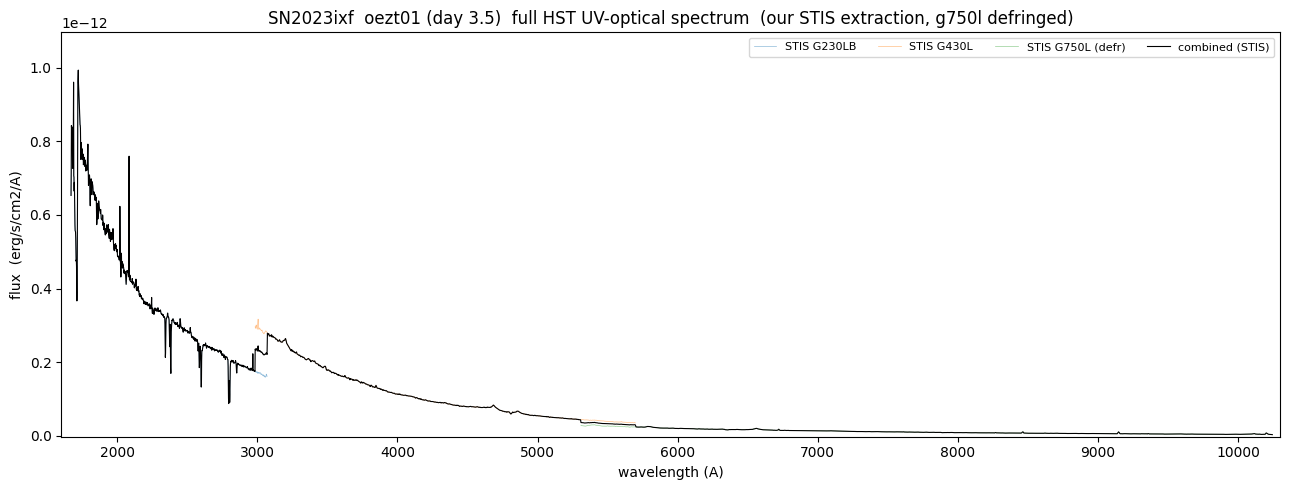

In [6]:
hst = '../data/2023ixf/mastDownload/HST'

def clean(w, f):
    # sort + drop non-increasing wavelengths so interp behaves (gratings/coadds can have splice dupes)
    o = np.argsort(w); w, f = w[o], f[o]
    keep = np.concatenate([[True], np.diff(w) > 0])
    return w[keep], f[keep]

def load_stis(root):
    t = fits.getdata(f'{hst}/{root}/{root}_x1d.fits', 1)[0]
    w, f, dq = t['WAVELENGTH'], t['FLUX'], t['DQ']
    g = (dq & 16 != 16) & (dq & 512 != 512) & np.isfinite(f) & (f != 0)
    return clean(np.asarray(w[g], float), np.asarray(f[g], float))

# oezt01 early epoch (day 3.5), all 3 stis gratings. the COS NUV is a separate day~214 obs
# (shown in the late-time cell below), so it is NOT combined here.
comps = {
    'STIS G230LB': load_stis('oezt01040'),
    'STIS G430L': load_stis('oezt010h0'),
    'STIS G750L (defr)': load_stis('oezt010e0'),
}

# common axis: fine in the UV, coarser to the red (like combine_spectra_reference)
newax = np.concatenate([np.arange(1650, 3050, 1.4), np.arange(3050, 5600, 2.7), np.arange(5600, 10260, 4.9)])

stack = []
fig, ax = plt.subplots(figsize=(13, 5))
for nm, (w, f) in comps.items():
    o = np.interp(newax, w, f, left=np.nan, right=np.nan)
    stack.append(o)
    ax.plot(newax, o, lw=0.5, alpha=0.5, label=nm)
comb = np.nanmedian(np.vstack(stack), axis=0)
ax.plot(newax, comb, lw=0.8, color='k', label='combined (STIS)')
ax.set_xlim(1600, 10300); ax.set_ylim(-0.2e-14, np.nanpercentile(comb, 99.5) * 1.3)
ax.set_xlabel('wavelength (A)'); ax.set_ylabel('flux  (erg/s/cm2/A)')
ax.set_title('SN2023ixf  oezt01 (day 3.5)  full HST UV-optical spectrum  (our STIS extraction, g750l defringed)')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

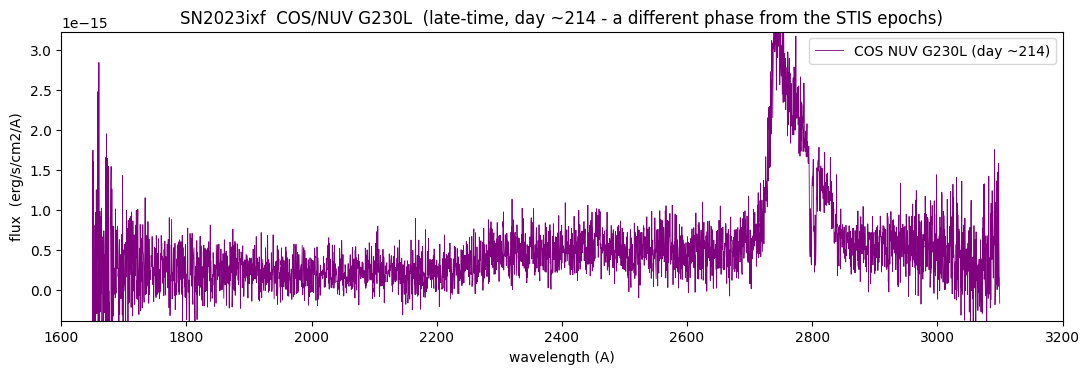

In [8]:
# the COS NUV G230L is a SEPARATE late-time observation (lf8803, prop 17497), not part of the stis
# epochs above. EXPSTART vs explosion (mjd ~60082.79) puts it at day ~214 - later than every stis
# epoch (day 3.5-66.5), so it's a different phase entirely and shown on its own here.
cspec = [p for p in glob(f'{hst}/hst_hasp_17497*/*_cspec.fits') if 'lf88_cspec' in p][0]
hc = fits.getdata(cspec, 1)[0]
w, f, eff = hc['WAVELENGTH'], hc['FLUX'], hc['EFF_EXPTIME']
m = (eff > 0) & np.isfinite(f) & (w > 1650) & (w < 3100)   # real coverage only, science window
cw, cf = clean(np.asarray(w[m], float), np.asarray(f[m], float))
phase = fits.getheader(f'{hst}/lf8803d5q/lf8803d5q_corrtag.fits', 1)['EXPSTART'] - 60082.79

plt.figure(figsize=(11, 4))
plt.plot(cw, cf, lw=0.6, color='purple', label=f'COS NUV G230L (day ~{phase:.0f})')
lo, hi = np.nanpercentile(cf, [2, 97])   # blue edge has huge-error spikes, clip them off the y-scale
plt.xlim(1600, 3200); plt.ylim(lo - abs(lo), hi * 1.5)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)'); plt.legend()
plt.title('SN2023ixf  COS/NUV G230L  (late-time, day ~214 - a different phase from the STIS epochs)')
plt.tight_layout(); plt.show()

### paper-driven checks (Bostroem et al. 2024, sec 2)

three quick validations against the 2023ixf UV paper, run on our own extraction of this epoch:
- **fringe-flat aperture** - our g750l defringe should use a narrower slit than the science exposure
  (paper used a small-aperture contemporaneous flat). confirm 52x0.1 flat vs 52x0.2 science.
- **saturation** - the paper says the early visit-1 g430l is saturated ~3200-5000A and unreliable for
  absolute flux. we flag the saturated pixels ourselves (dq bit 256) and shade the band.
- **inter-grating scaling** - the paper aligns the gratings onto one flux scale with a constant %
  (anchor g230lb). we keep the naive median as the primary coadd and show the scaled version as a
  comparison (decision: naive stays primary until we settle the absolute-flux anchoring).

In [9]:
# fringe flat should be a narrower slit than the science g750l (small-aperture contemporaneous flat)
for nm, root in [('g750l sci', 'oezt010e0'), ('fringe flat', 'oezt010d0')]:
    h = fits.getheader(f'{hst}/{root}/{root}_raw.fits', 0)
    print(nm, root, 'APERTURE =', h.get('APERTURE'))

# saturation extent per grating (dq bit 256). paper flags g430l ~3200-5000A saturated in the early visit.
print()
gr = {'g230lb': 'oezt01040', 'g430l': 'oezt010h0', 'g750l': 'oezt010e0'}
sat = {}
for nm, root in gr.items():
    t = fits.getdata(f'{hst}/{root}/{root}_x1d.fits', 1)[0]
    w, dq = np.asarray(t['WAVELENGTH'], float), np.asarray(t['DQ'], int)
    m = (dq & 256) == 256
    if m.any():
        sat[nm] = (w[m].min(), w[m].max())
        print(f'{nm:7s} {m.sum():4d} sat px   {w[m].min():.0f}-{w[m].max():.0f} A')
    else:
        print(f'{nm:7s} none')

g750l sci oezt010e0 APERTURE = 52X0.2
fringe flat oezt010d0 APERTURE = 52X0.1

g230lb     3 sat px   1941-2650 A
g430l    668 sat px   3178-5022 A
g750l      3 sat px   6233-8753 A


g430l x0.595   g750l x0.913


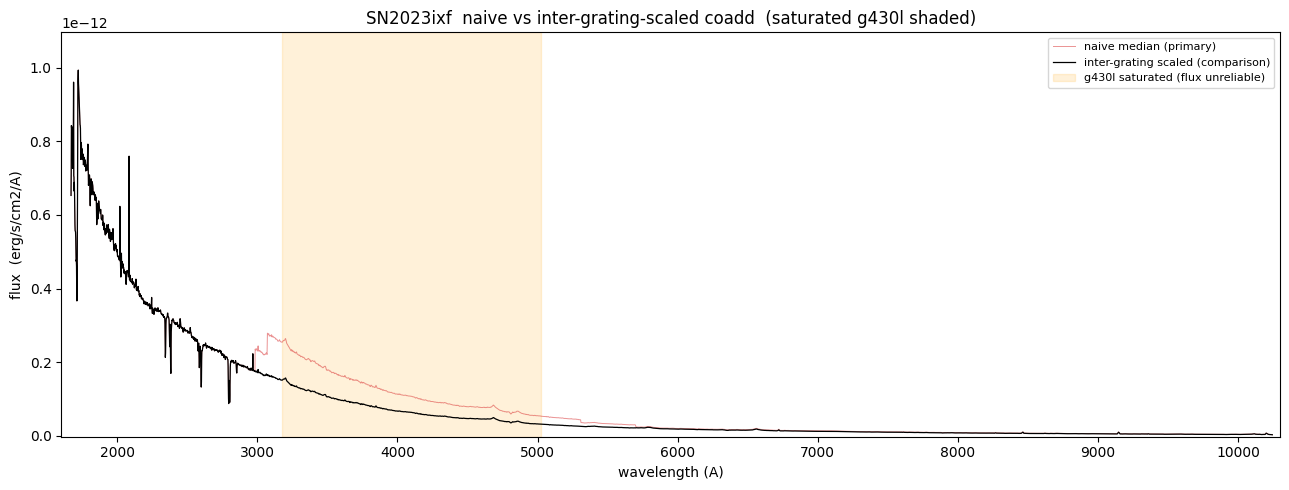

In [10]:
# inter-grating constant-% scaling (bostroem 2024 flux-cal trick), anchor on g230lb.
# overlaps are at the clean grating edges, away from the saturated mid-g430l.
# caveat: g230lb's red end droops near 3060 so the g430l factor is a bit edge-biased.
g230, g430, g750 = comps['STIS G230LB'], comps['STIS G430L'], comps['STIS G750L (defr)']
i230 = np.interp(newax, *g230, left=np.nan, right=np.nan)
i430 = np.interp(newax, *g430, left=np.nan, right=np.nan)
i750 = np.interp(newax, *g750, left=np.nan, right=np.nan)

def ratio(a, b, lo, hi):
    m = (newax >= lo) & (newax <= hi)
    return np.nanmedian(a[m]) / np.nanmedian(b[m])

s430 = ratio(i230, i430, 2950, 3050)    # g430l -> g230lb
i430s = i430 * s430
s750 = ratio(i430s, i750, 5300, 5550)   # g750l -> scaled g430l
i750s = i750 * s750
print(f'g430l x{s430:.3f}   g750l x{s750:.3f}')

scaled = np.nanmedian(np.vstack([i230, i430s, i750s]), axis=0)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(newax, comb, lw=0.7, alpha=0.5, color='tab:red', label='naive median (primary)')
ax.plot(newax, scaled, lw=0.9, color='k', label='inter-grating scaled (comparison)')
if 'g430l' in sat:
    ax.axvspan(*sat['g430l'], color='orange', alpha=0.15, label='g430l saturated (flux unreliable)')
ax.set_xlim(1600, 10300); ax.set_ylim(-0.2e-14, np.nanpercentile(scaled, 99.5) * 1.3)
ax.set_xlabel('wavelength (A)'); ax.set_ylabel('flux  (erg/s/cm2/A)')
ax.set_title('SN2023ixf  naive vs inter-grating-scaled coadd  (saturated g430l shaded)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [7]:
# paper figure 1 time series. 9-epoch plan, colors run early(top) -> late(bottom).
# only the first 5 have data now (the pre-14d 1d spectra); day 14/19/24/66 get filled
# in once we reduce them ourselves further down.
early_dir = '../data/earlytime_2023ixf'
epoch_plan = [
    ('3.25',  'darkblue',   'scaled_ebv_corr_combined_spec_1st_hst.txt'),
    ('4.25',  'indigo',     'scaled_ebv_corr_combined_spec_2nd_hst.txt'),
    ('5.25',  'darkviolet', 'scaled_ebv_corr_combined_spec_3rd_hst.txt'),
    ('8.25',  'magenta',    'scaled_ebv_corr_combined_spec_4th_hst.txt'),
    ('11.25', 'deeppink',   'scaled_ebv_corr_combined_spec_5th_hst.txt'),
    ('14.25', 'crimson',    None),
    ('19.25', 'red',        None),
    ('24.25', 'darkorange', None),
    ('66.25', 'gold',       None),
]
# cols: WAVELENGTH FLUX ERROR ORIGFLUX FLUX_corr. FLUX=scaled combined, FLUX_corr=+ebv dereddened.
fluxcol = 1   # 1=FLUX, 4=FLUX_corr. swap to 4 for the dereddened version.

epochs = []   # (day, color, plan_idx, wvl, flx)
for idx, (day, col, fname) in enumerate(epoch_plan):
    if fname is None:
        continue  # day 14+ reductions get appended later
    d = np.loadtxt(f'{early_dir}/{fname}', skiprows=1)
    w, f = d[:, 0], d[:, fluxcol]
    m = np.isfinite(f) & (f > 0)   # log axis wants positives only
    epochs.append((day, col, idx, w[m], f[m]))
print(len(epochs), 'epochs loaded:', [e[0] for e in epochs])

5 epochs loaded: ['3.25', '4.25', '5.25', '8.25', '11.25']


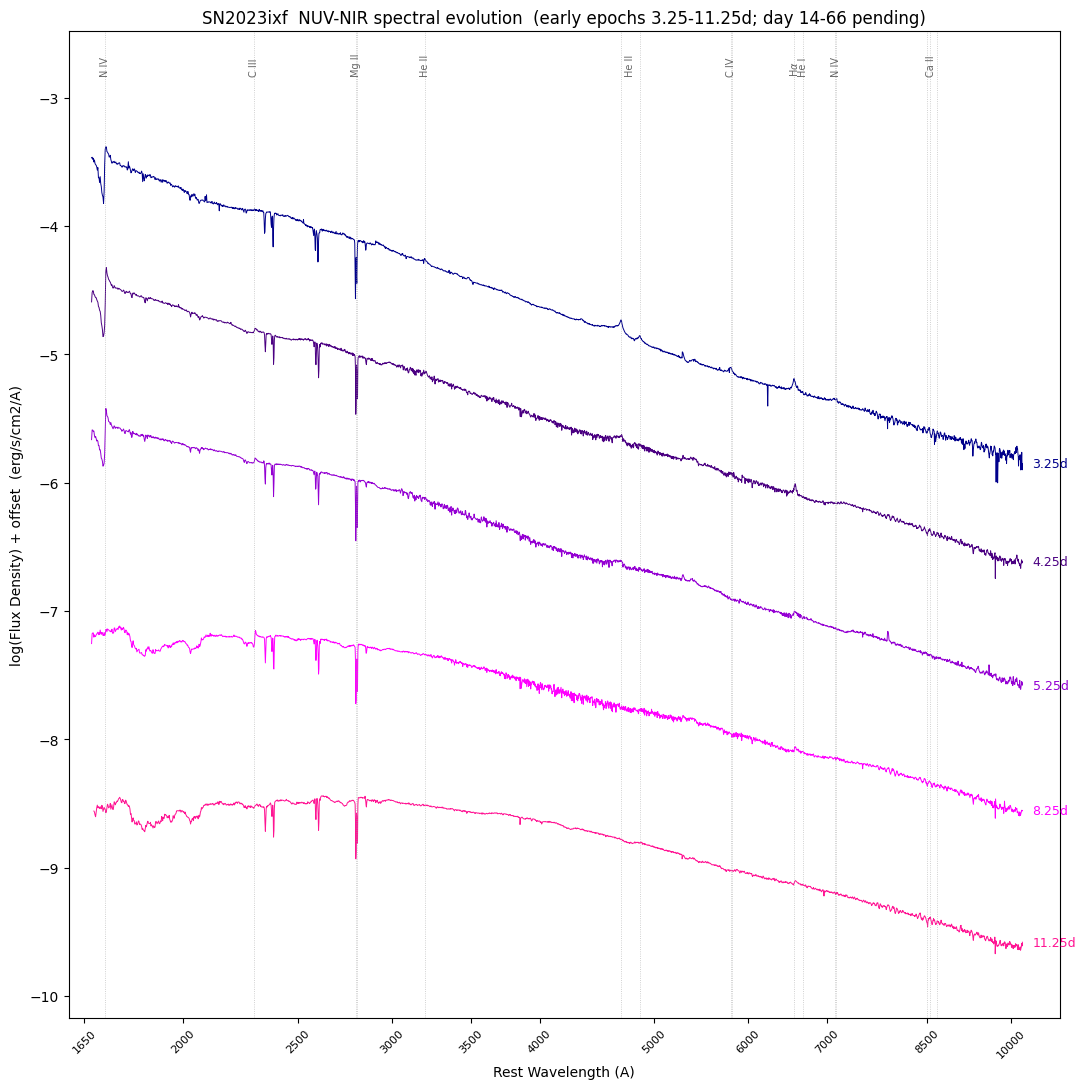

In [8]:
# atomic transitions from the paper, marked as dotted verticals + labeled at top
lines = [
    ('N IV',  [1718]),
    ('C III', [2297]),
    ('Mg II', [2796, 2802]),
    ('He II', [3203]),
    ('He II', [4685.5, 4860]),
    ('C IV',  [5801, 5812]),
    (r'H$\alpha$', [6563]),
    ('He I',  [6678.1]),
    ('N IV',  [7109, 7122]),
    ('Ca II', [8498, 8542, 8662]),
]
xticks = [1650, 2000, 2500, 3000, 3500, 4000, 5000, 6000, 7000, 8500, 10000]
step = 1.0        # log-flux offset between epoch slots, big enough the traces don't overlap
nslot = len(epoch_plan)

def plot_ts(eps, title, savepath):
    fig, ax = plt.subplots(figsize=(11, 11))
    ally = []
    for day, col, idx, w, f in sorted(eps, key=lambda e: e[2]):
        y = np.log10(f) + (nslot - 1 - idx) * step   # earliest epoch ends up on top
        ax.plot(w, y, color=col, lw=0.7)
        ax.text(w[-1] * 1.02, y[-1], f'{day}d', color=col, fontsize=9, va='center')
        ally.append(y)
    ally = np.concatenate(ally)
    ylo, yhi = np.nanmin(ally), np.nanmax(ally)
    ax.set_ylim(ylo - 0.5, yhi + 0.9)
    for lab, wls in lines:
        for wl in wls:
            ax.axvline(wl, color='0.6', ls=':', lw=0.6, alpha=0.6)
        ax.text(np.mean(wls), yhi + 0.55, lab, rotation=90, fontsize=7, color='0.4', va='bottom', ha='center')
    ax.set_xscale('log')
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks], rotation=45, fontsize=8)
    ax.minorticks_off()
    ax.set_xlim(1600, 11000)
    ax.set_xlabel('Rest Wavelength (A)')
    ax.set_ylabel('log(Flux Density) + offset  (erg/s/cm2/A)')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(savepath, dpi=130, bbox_inches='tight')
    plt.show()

plot_ts(epochs, 'SN2023ixf  NUV-NIR spectral evolution  (early epochs 3.25-11.25d; day 14-66 pending)',
        '../output/2023ixf_timeseries.png')

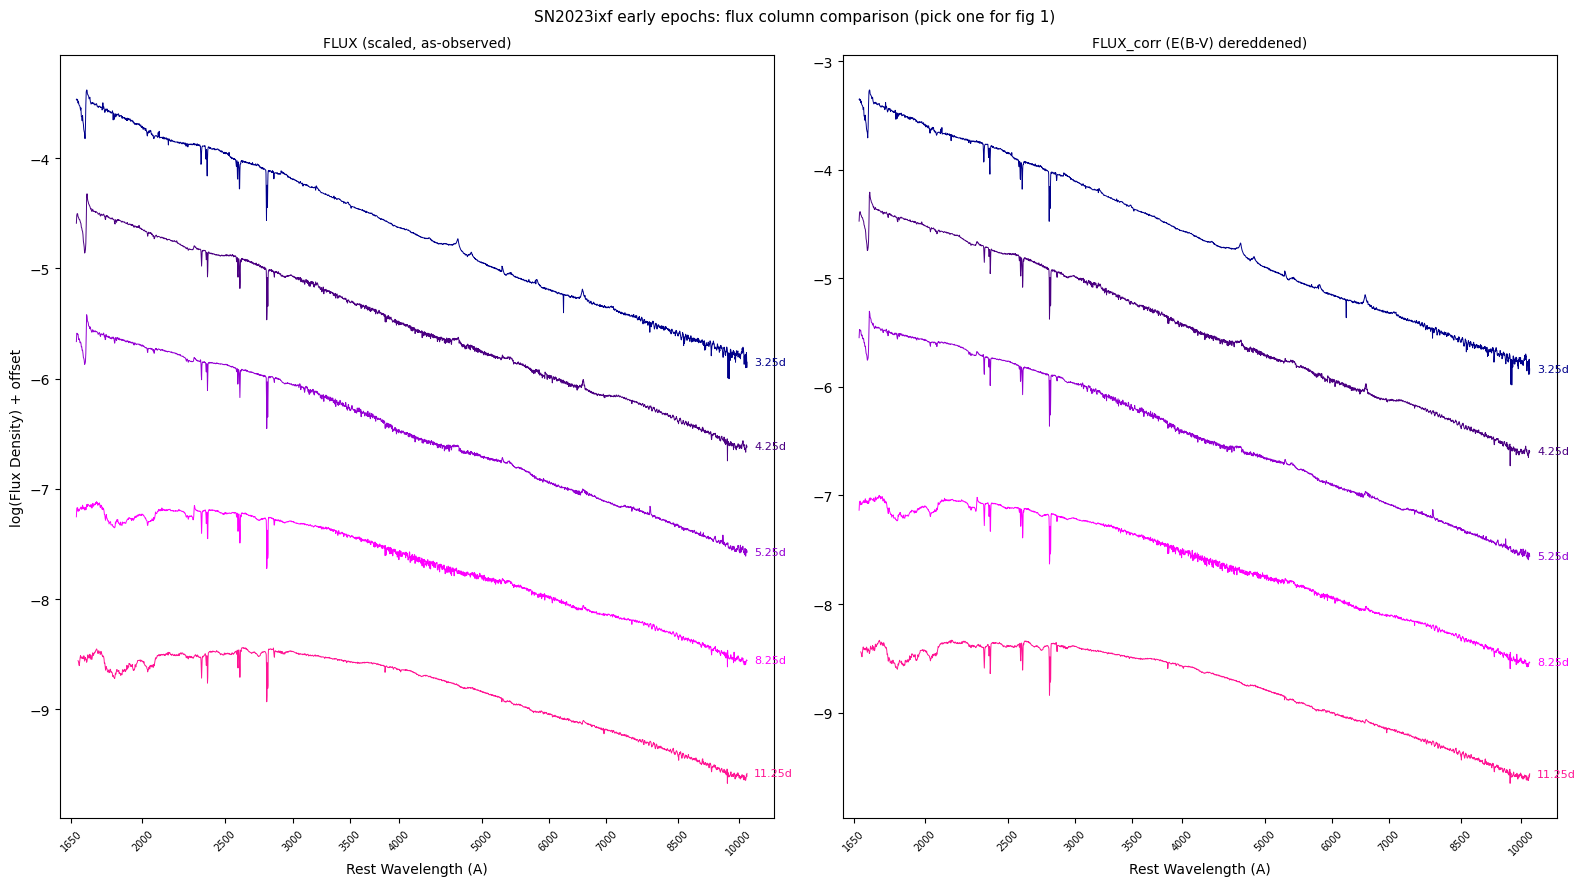

In [13]:
# flux-column comparison: FLUX (scaled) vs FLUX_corr (ebv-dereddened). which one for the fig 1 repro?
# dereddening boosts the uv more than the red, so the corrected version has a steeper blue continuum.
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, (fc, ttl) in zip(axes, [(1, 'FLUX (scaled, as-observed)'), (4, 'FLUX_corr (E(B-V) dereddened)')]):
    for idx, (day, col, fname) in enumerate(epoch_plan):
        if fname is None:
            continue
        d = np.loadtxt(f'{early_dir}/{fname}', skiprows=1)
        w, f = d[:, 0], d[:, fc]
        m = np.isfinite(f) & (f > 0)
        y = np.log10(f[m]) + (nslot - 1 - idx) * step
        ax.plot(w[m], y, color=col, lw=0.7)
        ax.text(w[m][-1] * 1.02, y[-1], f'{day}d', color=col, fontsize=8, va='center')
    ax.set_xscale('log'); ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks], rotation=45, fontsize=7)
    ax.minorticks_off(); ax.set_xlim(1600, 11000)
    ax.set_xlabel('Rest Wavelength (A)'); ax.set_title(ttl, fontsize=10)
axes[0].set_ylabel('log(Flux Density) + offset')
fig.suptitle('SN2023ixf early epochs: flux column comparison (pick one for fig 1)', fontsize=11)
plt.tight_layout()
plt.savefig('../output/2023ixf_timeseries_fluxcompare.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# identify the day 14-66 main epochs. the early go-17205 (oezt*) set is the saturated one we skip;
# the main program (days 14/19/24/66, E1 slit) is a separate proposal. cone-search + list by date.
import pandas as pd
from astropy.time import Time
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 200)

obs = Observations.query_criteria(objectname='SN2023ixf', radius='0.05 deg',
                                  obs_collection='HST', dataproduct_type='spectrum')
df = obs.to_pandas()
stis = df[df['instrument_name'].astype(str).str.contains('STIS', na=False)].copy()
stis['date'] = Time(stis['t_min'].astype(float), format='mjd').isot
texp = 60082.8   # rough explosion epoch (mjd, ~2023-05-18.8) just to sort into phases
stis['phase'] = (stis['t_min'].astype(float) - texp).round(1)
cols = ['obs_id', 'proposal_id', 'filters', 'phase', 'date', 't_exptime', 'target_name']
print(stis[cols].sort_values('phase').to_string(index=False))

                             obs_id proposal_id                 filters   phase                    date    t_exptime            target_name
                          o54sb4koq        8084                   G750L -8953.9 1998-11-11T21:26:37.913    10.000000                   NONE
                          o54sb5lbq        8084                   G750L -8953.9 1998-11-11T22:44:28.923    10.000000                   NONE
                          o6dcc8050        9066                   G750L -7827.1 2001-12-12T15:53:07.953  1800.000000 HIGH-GALACTIC-LATITUDE
                          o6dcca0f0        9066                   G750L -7822.3 2001-12-17T12:41:39.953  1800.000000 HIGH-GALACTIC-LATITUDE
                          o6dcca0e0        9066                   G750L -7822.2 2001-12-17T14:08:31.953  1730.000000 HIGH-GALACTIC-LATITUDE
                          o6j3mldyq        9285                   G750L -7822.1 2001-12-17T16:43:32.977  1500.000000      HI-LATITUDE-FIELD
                    

In [15]:
# find each of43 visit's ccdflat (g750l fringe flat) - not returned by the spectrum query above.
allof43 = Observations.query_criteria(proposal_id='17313', obs_id='of43*').to_pandas()
a = allof43[['obs_id', 'target_name', 'filters', 'dataproduct_type', 't_exptime']].sort_values('obs_id')
print(a.to_string(index=False))

   obs_id target_name filters dataproduct_type   t_exptime
of4301010   SN2023IXF  G230LB         spectrum 1158.000000
of4301020   SN2023IXF   G430L         spectrum   36.000000
of4301030   SN2023IXF   G750L         spectrum   28.000000
of4301040     CCDFLAT   G750L         spectrum   50.000000
of4301adq   SN2023IXF  MIRVIS            image    5.100000
of4302010   SN2023IXF  G230LB         spectrum 1244.000000
of4302020   SN2023IXF   G430L         spectrum   32.000000
of4302030   SN2023IXF   G750L         spectrum   24.000000
of4302040     CCDFLAT   G750L         spectrum   50.000000
of4302n9q   SN2023IXF  MIRVIS            image   10.100000
of4303010   SN2023IXF  G230LB         spectrum 1232.000000
of4303020   SN2023IXF   G430L         spectrum   34.000000
of4303030   SN2023IXF   G750L         spectrum   26.000000
of4303040     CCDFLAT   G750L         spectrum   50.000000
of4303fgq   SN2023IXF  MIRVIS            image   14.100000
of4304010   SN2023IXF  G230LB         spectrum    3.0728

In [16]:
# download the 4 main epochs into per-epoch dirs. each of43 visit: 010 g230lb, 020 g430l,
# 030 g750l, 040 ccdflat (the g750l fringe flat). of4304 skipped (failed guide-star acq).
main_epochs = [
    (14, 'of4301', ['of4301010', 'of4301020', 'of4301030', 'of4301040']),
    (19, 'of4302', ['of4302010', 'of4302020', 'of4302030', 'of4302040']),
    (24, 'of4303', ['of4303010', 'of4303020', 'of4303030', 'of4303040']),
    (66, 'of4305', ['of4305010', 'of4305020', 'of4305030', 'of4305040']),
]
keep_suffix = ('_flt.fits', '_crj.fits', '_wav.fits', '_raw.fits', '_sx1.fits')
for d, visit, roots in main_epochs:
    dd = f'../data/2023ixf/epochs/day{d}_{visit}'
    pl = Observations.get_product_list(Observations.query_criteria(obs_id=roots))
    keep = [f.endswith(keep_suffix) for f in pl['productFilename']]
    print(f'day {d} ({visit}): {sum(keep)} files -> {dd}')
    Observations.download_products(pl[keep], download_dir=dd, mrp_only=False)
print('done')

day 14 (of4301): 17 files -> ../data/2023ixf/epochs/day14_of4301
INFO: Found cached file ../data/2023ixf/epochs/day14_of4301\mastDownload\HST\of4301040\of4301040_raw.fits with expected size 4501440. [astroquery.query]
INFO: Found cached file ../data/2023ixf/epochs/day14_of4301\mastDownload\HST\of4301040\of4301040_flt.fits with expected size 21049920. [astroquery.query]
INFO: Found cached file ../data/2023ixf/epochs/day14_of4301\mastDownload\HST\of4301020\of4301020_crj.fits with expected size 10537920. [astroquery.query]
INFO: Found cached file ../data/2023ixf/epochs/day14_of4301\mastDownload\HST\of4301020\of4301020_wav.fits with expected size 2260800. [astroquery.query]
INFO: Found cached file ../data/2023ixf/epochs/day14_of4301\mastDownload\HST\of4301020\of4301020_raw.fits with expected size 4501440. [astroquery.query]
INFO: Found cached file ../data/2023ixf/epochs/day14_of4301\mastDownload\HST\of4301020\of4301020_flt.fits with expected size 21052800. [astroquery.query]
INFO: Found ca

### reduce + coadd the day 14-66 epochs (our own extraction)

the main-program epochs (prop 17313, of43 visits, E1 slit) at days 14/19/24/66. these are CRSPLIT>1
so mast gives a cr-combined `crj` per grating; we extract off that with our own `x1d` (g230lb/g430l)
and defringe the g750l with the contemporaneous ccdflat (`of43NN040`, the narrow 0.3x0.09 E1 flat) -
the paper's recipe. runs in wsl via `reduce_epoch_ts.py`. the day-66 g230lb blue flux is so low the
auto trace-find fails (the paper hit this too), so the reducer retries with a fixed E1 trace center
(a2center=893.5, maxsrch=0). then we coadd each epoch's 3 gratings and append to `epochs`, and the
same `plot_ts` fills in the lower half of figure 1.

caveat to revisit: the early spectra are scaled + ebv-dereddened, our day 14-66 coadds are raw
flux (no dereddening / inter-grating scaling yet), so the two halves aren't on an identical flux
system - fine for the stacked log view, flagged in `pipeline_phase2.md` P2.3.

In [17]:
# reduce the 4 main epochs in wsl (surf_uv) via reduce_epoch_ts.py. idempotent: skips epochs whose
# 3 x1d already exist. g230lb/g430l extract off the mast crj; g750l is defringed with the ccdflat.
import subprocess
wslroot = '/mnt/c/Users/eluru/CALTECH_SURF_2026/WORK'
for d, visit, roots in main_epochs:
    epdir = f'../data/2023ixf/epochs/day{d}_{visit}/mastDownload/HST'
    if all(os.path.exists(f'{epdir}/{visit}{g}/{visit}{g}_x1d.fits') for g in ('010', '020', '030')):
        print(f'day {d}: x1d present, skip'); continue
    base = f'{wslroot}/data/2023ixf/epochs/day{d}_{visit}/mastDownload/HST'
    cmd = ('source ~/miniforge3/etc/profile.d/conda.sh && conda activate surf_uv && '
           f'cd {wslroot} && python scripts/reduce_epoch_ts.py {base} '
           f'g230lb={visit}010 g430l={visit}020 g750l={visit}030 flat={visit}040')
    print(f'day {d}: reducing in wsl...')
    subprocess.run(['wsl.exe', '-d', 'Debian', '--', 'bash', '-lc', cmd], check=True)
print('reduction done')

day 14: x1d present, skip
day 19: x1d present, skip
day 24: x1d present, skip
day 66: x1d present, skip
reduction done


In [9]:
# coadd each main epoch's 3 gratings, with inter-grating flux scaling: align g430l + g750l to g230lb
# by a constant factor in the overlaps (the paper's trick). unsaturated epochs come out ~1 (confirming
# the gratings agree); a factor far from 1 means the overlap sits on a faint/edge region and is
# unreliable (saturated oezt01, or day-66's faded blue end) - guard those to 1. then median + append.
main_meta = [   # (day, visit, color, plan_idx matching the epoch_plan slots)
    ('14.25', 'of4301', 'crimson',    5),
    ('19.25', 'of4302', 'red',        6),
    ('24.25', 'of4303', 'darkorange', 7),
    ('66.25', 'of4305', 'gold',       8),
]
def load_x1d(path):
    t = fits.getdata(path, 1)[0]
    w, f, dq = t['WAVELENGTH'], t['FLUX'], t['DQ']
    g = (dq & 16 != 16) & (dq & 512 != 512) & np.isfinite(f) & (f != 0)
    return clean(np.asarray(w[g], float), np.asarray(f[g], float))

def scale(a, b, lo, hi):
    m = (newax >= lo) & (newax <= hi) & np.isfinite(a) & np.isfinite(b)
    r = np.nanmedian(a[m]) / np.nanmedian(b[m]) if m.any() else np.nan
    s = r if np.isfinite(r) and 0.7 < r < 1.4 else 1.0   # outside +-40% = edge/faint artifact, don't scale
    return s, r

epochs = [e for e in epochs if e[2] < 5]    # keep the 5 early, drop any appended main (idempotent)
for day, visit, color, idx in main_meta:
    base = f"../data/2023ixf/epochs/day{int(float(day))}_{visit}/mastDownload/HST"
    g230 = np.interp(newax, *load_x1d(f'{base}/{visit}010/{visit}010_x1d.fits'), left=np.nan, right=np.nan)
    g430 = np.interp(newax, *load_x1d(f'{base}/{visit}020/{visit}020_x1d.fits'), left=np.nan, right=np.nan)
    g750 = np.interp(newax, *load_x1d(f'{base}/{visit}030/{visit}030_x1d.fits'), left=np.nan, right=np.nan)
    s430, r430 = scale(g230, g430, 2950, 3050)             # g430l -> g230lb
    s750, r750 = scale(g430 * s430, g750, 5300, 5550)      # g750l -> scaled g430l
    comb = np.nanmedian(np.vstack([g230, g430 * s430, g750 * s750]), axis=0)
    m = np.isfinite(comb) & (comb > 0)
    epochs.append((day, color, idx, newax[m], comb[m]))
    print(f"day {day}: g430l x{s430:.3f} (raw {r430:.2f})  g750l x{s750:.3f} (raw {r750:.2f})")
print('epochs now:', [(e[0], e[2]) for e in sorted(epochs, key=lambda e: e[2])])

day 14.25: g430l x0.995 (raw 0.99)  g750l x1.016 (raw 1.02)
day 19.25: g430l x1.030 (raw 1.03)  g750l x1.075 (raw 1.07)
day 24.25: g430l x1.006 (raw 1.01)  g750l x1.026 (raw 1.03)
day 66.25: g430l x1.000 (raw 1.88)  g750l x1.049 (raw 1.05)
epochs now: [('3.25', 0), ('4.25', 1), ('5.25', 2), ('8.25', 3), ('11.25', 4), ('14.25', 5), ('19.25', 6), ('24.25', 7), ('66.25', 8)]


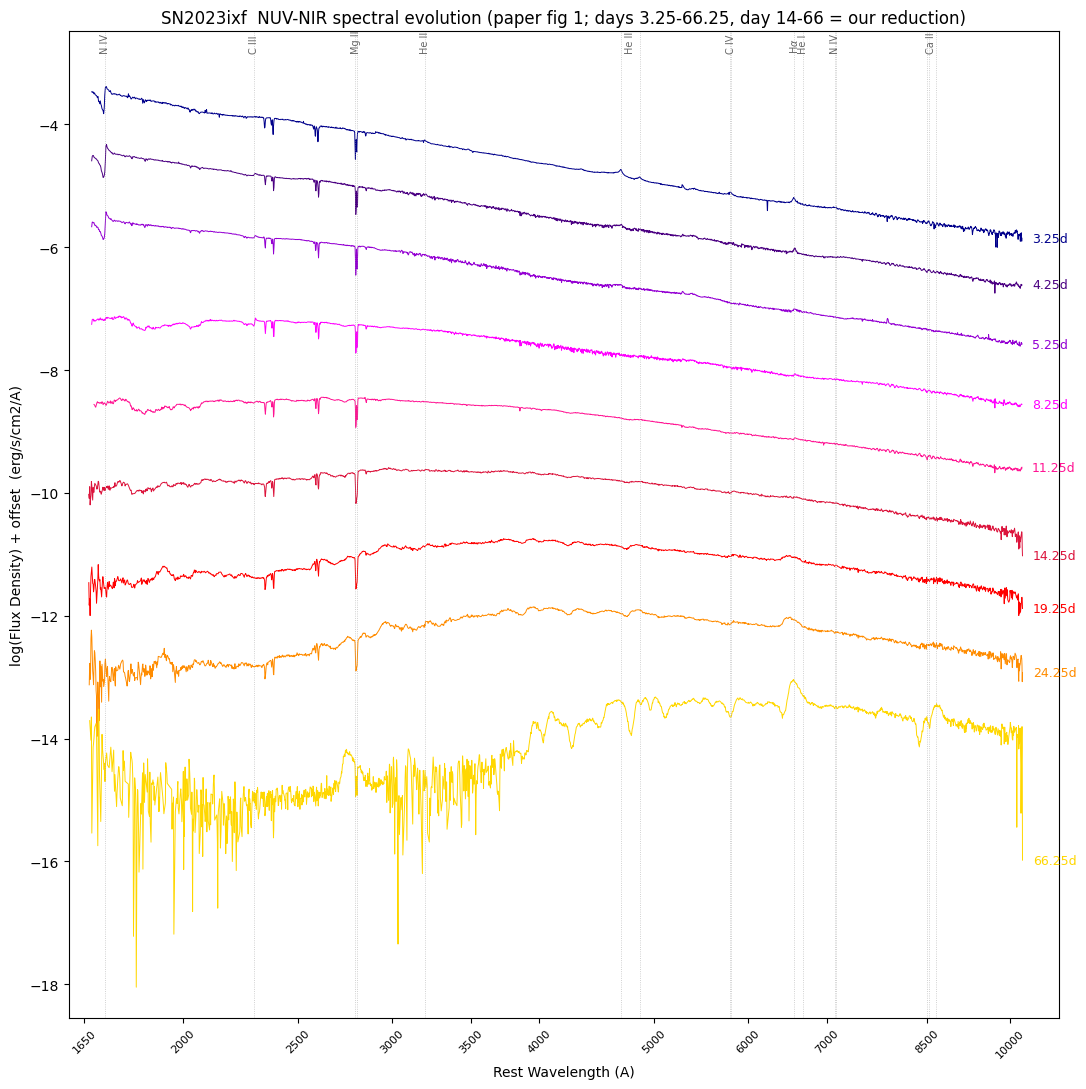

In [19]:
# full 9-epoch figure 1: the early epochs + our own day 14-66 reductions
plot_ts(epochs, 'SN2023ixf  NUV-NIR spectral evolution (paper fig 1; days 3.25-66.25, day 14-66 = our reduction)',
        '../output/2023ixf_timeseries_full.png')

In [2]:
# full 2023ixf spectroscopy landscape - every hst spectrum, collapsed to one row per visit, by phase.
# goal: see the whole time series we could build (out to ~1000d) and count how many COS epochs there are.
import numpy as np, pandas as pd
from astropy.time import Time
from astroquery.mast import Observations
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 170)

TEXP = 60082.79   # sn2023ixf explosion mjd (~2023-05-18.8)

obs = Observations.query_criteria(objectname='SN2023ixf', radius='0.05 deg',
                                  obs_collection='HST', dataproduct_type='spectrum')
d = obs.to_pandas()
d['inst']  = d['instrument_name'].astype(str)
d['phase'] = (d['t_min'].astype(float) - TEXP).round(1)
d = d[d['phase'] > 0]                                          # post-explosion only
d = d[~d['obs_id'].astype(str).str.startswith('hst_')].copy()  # drop hasp/hsla coadd products, keep raw datasets
d['visit'] = d['obs_id'].astype(str).str[:6]                   # IPPPSS = instrument + prop + visit id
d['date']  = [s[:10] for s in Time(d['t_min'].astype(float), format='mjd').isot]

vis = d.groupby('visit').agg(
    phase_d = ('phase', 'min'),
    date    = ('date', 'first'),
    prop    = ('proposal_id', 'first'),
    inst    = ('inst', lambda x: '/'.join(sorted(set(x)))),
    gratings= ('filters', lambda x: '+'.join(sorted(set(x.astype(str))))),
    n_exp   = ('obs_id', 'size'),
).sort_values('phase_d')

print(f"SN2023ixf HST spectroscopy - {len(vis)} visits, phase {vis['phase_d'].min():.0f} to {vis['phase_d'].max():.0f} d")
print(f"most recent: {vis['date'].iloc[-1]}\n")
print(vis.to_string())

cos = vis[vis['inst'].str.contains('COS')]
print(f"\n=== COS visits: {len(cos)} (PI says should be 1) ===")
print(cos.to_string())

SN2023ixf HST spectroscopy - 28 visits, phase 3 to 1094 d
most recent: 2026-05-16

        phase_d        date   prop                         inst            gratings  n_exp
visit                                                                                     
oezt01      3.4  2023-05-22  17205                     STIS/CCD  G230LB+G430L+G750L     16
oezt02      4.4  2023-05-23  17205                     STIS/CCD  G230LB+G430L+G750L     16
oezt03      5.4  2023-05-24  17205                     STIS/CCD  G230LB+G430L+G750L     16
oezt04      8.6  2023-05-27  17205                     STIS/CCD  G230LB+G430L+G750L     13
oezt05     11.5  2023-05-30  17205                     STIS/CCD  G230LB+G430L+G750L     10
of4301     14.4  2023-06-02  17313                     STIS/CCD  G230LB+G430L+G750L      3
of4302     19.9  2023-06-07  17313                     STIS/CCD  G230LB+G430L+G750L      3
of4303     24.7  2023-06-12  17313                     STIS/CCD  G230LB+G430L+G750L      3
of4304 

In [3]:
# verify the two COS visits actually point at the SN (cone was 3' and M101 is ~28' across)
from astropy.coordinates import SkyCoord
import astropy.units as u

sn = SkyCoord.from_name('SN2023ixf')
cosrows = d[d['inst'].str.contains('COS')][['obs_id','proposal_id','target_name','s_ra','s_dec','phase']].copy()
cc = SkyCoord(cosrows['s_ra'].astype(float).values * u.deg, cosrows['s_dec'].astype(float).values * u.deg)
cosrows['sep_arcsec'] = sn.separation(cc).arcsec.round(1)
print(f"SN2023ixf resolved position: RA={sn.ra.deg:.5f}  Dec={sn.dec.deg:.5f}\n")
print(cosrows.to_string(index=False))

SN2023ixf resolved position: RA=210.91067  Dec=54.31165

   obs_id proposal_id   target_name       s_ra     s_dec  phase  sep_arcsec
lf8803050       17497 SN2023IXF-COS 210.910683 54.311667  214.2         0.1
lf8803020       17497 SN2023IXF-COS 210.910683 54.311667  214.1         0.1
lf9256010       17494  M101-209+312 210.754850 54.241432  632.0       413.7
lf8803030       17497 SN2023IXF-COS 210.910683 54.311667  214.1         0.1
lf8803010       17497 SN2023IXF-COS 210.910683 54.311667  214.1         0.1
lf8803040       17497 SN2023IXF-COS 210.910683 54.311667  214.2         0.1
lf8803060       17497 SN2023IXF-COS 210.910683 54.311667  214.2         0.1


In [4]:
# download the remaining epochs (days 183-1094) for the full series. skip: the days 3-66 optical
# epochs we already have (oezt*, of43*), the COS NUV we have (lf8803), and lf9256 (a different M101
# target, not the SN - verified above). keep the standard science products per visit.
skip = tuple(['oezt', 'of43']) 
todo = vis[~(vis.index.str.startswith(skip) | vis.index.isin(['lf8803', 'lf9256']))]
print("visits to download:", list(todo.index), "\n")

keep_suf = ('_flt.fits', '_x1d.fits', '_wav.fits', '_raw.fits', '_crj.fits', '_sx1.fits')
for v, row in todo.iterrows():
    ids = d[d['visit'] == v]['obs_id'].tolist()
    pl = Observations.get_product_list(Observations.query_criteria(obs_id=ids))
    keep = np.array([str(f).endswith(keep_suf) for f in pl['productFilename']])
    dd = f"../data/2023ixf/epochs/day{int(round(row['phase_d']))}_{v}"
    print(f"  {v} (day {row['phase_d']:.0f}, {row['inst']} {row['gratings']}): {keep.sum()} files -> {dd}")
    Observations.download_products(pl[keep], download_dir=dd, mrp_only=False, verbose=False)
print("\ndownload done")

visits to download: ['of8801', 'ofbp01', 'ofbp04', 'ofbp02', 'ofbp03', 'ofbp05', 'ofg001', 'ofg005', 'ofg003', 'ofg004', 'ofrs01', 'ofrs02', 'ofrs03', 'ofrs04', 'ofoz01', 'ofoz02'] 

  of8801 (day 183, STIS/FUV-MAMA G140L): 16 files -> ../data/2023ixf/epochs/day183_of8801
  ofbp01 (day 308, STIS/FUV-MAMA G140L): 8 files -> ../data/2023ixf/epochs/day308_ofbp01
  ofbp04 (day 311, STIS/NUV-MAMA G230L): 8 files -> ../data/2023ixf/epochs/day311_ofbp04
  ofbp02 (day 311, STIS/FUV-MAMA G140L): 8 files -> ../data/2023ixf/epochs/day311_ofbp02
  ofbp03 (day 312, STIS/FUV-MAMA G140L): 8 files -> ../data/2023ixf/epochs/day312_ofbp03
  ofbp05 (day 314, STIS/NUV-MAMA G230L): 8 files -> ../data/2023ixf/epochs/day314_ofbp05
  ofg001 (day 577, STIS/FUV-MAMA/STIS/NUV-MAMA G140L+G230L): 6 files -> ../data/2023ixf/epochs/day577_ofg001
  ofg005 (day 619, STIS/FUV-MAMA/STIS/NUV-MAMA G140L+G230L): 12 files -> ../data/2023ixf/epochs/day619_ofg005
  ofg003 (day 723, STIS/NUV-MAMA G230L): 20 files -> ../data/20

In [11]:
# assemble the late epochs (days 183-1094) from our own x1d. these are UV-only STIS MAMA
# (G140L FUV + G230L NUV) plus two narrow G750M Ha snippets. per visit we median-combine our
# x1d over exposures within each grating, then merge gratings; visits at the same phase are one epoch.
fullax = np.concatenate([np.arange(1120, 1650, 1.0), newax])   # extend blueward for FUV G140L

def load_x1d_any(path):
    t = fits.getdata(path, 1)[0]
    w, f, dq = t['WAVELENGTH'], t['FLUX'], t['DQ']
    g = (dq & 16 != 16) & (dq & 512 != 512) & np.isfinite(f) & (f != 0)
    return clean(np.asarray(w[g], float), np.asarray(f[g], float))

def visit_spec(vdir):
    byg = {}
    for x in sorted(glob(f'{vdir}/mastDownload/HST/*/*_x1d.fits')):
        gname = fits.getheader(x, 0)['OPT_ELEM']
        w, f = load_x1d_any(x)
        byg.setdefault(gname, []).append(np.interp(fullax, w, f, left=np.nan, right=np.nan))
    if not byg:
        return np.full(fullax.shape, np.nan)   # visit not reduced yet (no x1d)
    per_g = [np.nanmedian(np.vstack(v), axis=0) for v in byg.values()]
    return np.nanmedian(np.vstack(per_g), axis=0)

late_defs = [
    (183,  ['day183_of8801']),
    (311,  ['day308_ofbp01', 'day311_ofbp02', 'day312_ofbp03', 'day311_ofbp04', 'day314_ofbp05']),
    (577,  ['day577_ofg001']),
    (619,  ['day619_ofg005']),
    (723,  ['day723_ofg003', 'day724_ofg004']),
    (913,  ['day913_ofrs01', 'day914_ofrs02']),
    (924,  ['day924_ofrs03', 'day924_ofrs04']),
    (1094, ['day1094_ofoz01', 'day1094_ofoz02']),
]
late = []
for day, vdirs in late_defs:
    stack = [visit_spec(f'../data/2023ixf/epochs/{v}') for v in vdirs]
    comb = np.nanmedian(np.vstack(stack), axis=0)
    m = np.isfinite(comb) & (comb > 0)
    if m.sum() == 0:
        print(f"day {day:4d}:  no x1d yet, skipped  ({'+'.join(vdirs)})"); continue
    late.append((str(day), fullax[m], comb[m]))
    print(f"day {day:4d}: {m.sum():4d} pts  {fullax[m].min():.0f}-{fullax[m].max():.0f} A  ({'+'.join(vdirs)})")


day  183:  546 pts  1143-1713 A  (day183_of8801)
day  311: 1527 pts  1151-3144 A  (day308_ofbp01+day311_ofbp02+day312_ofbp03+day311_ofbp04+day314_ofbp05)
day  577:  no x1d yet, skipped  (day577_ofg001)
day  619: 1429 pts  1152-3153 A  (day619_ofg005)
day  723: 1440 pts  1140-3136 A  (day723_ofg003+day724_ofg004)
day  913: 1434 pts  1141-6859 A  (day913_ofrs01+day914_ofrs02)
day  924: 1475 pts  1139-6840 A  (day924_ofrs03+day924_ofrs04)
day 1094: 1368 pts  1139-3139 A  (day1094_ofoz01+day1094_ofoz02)


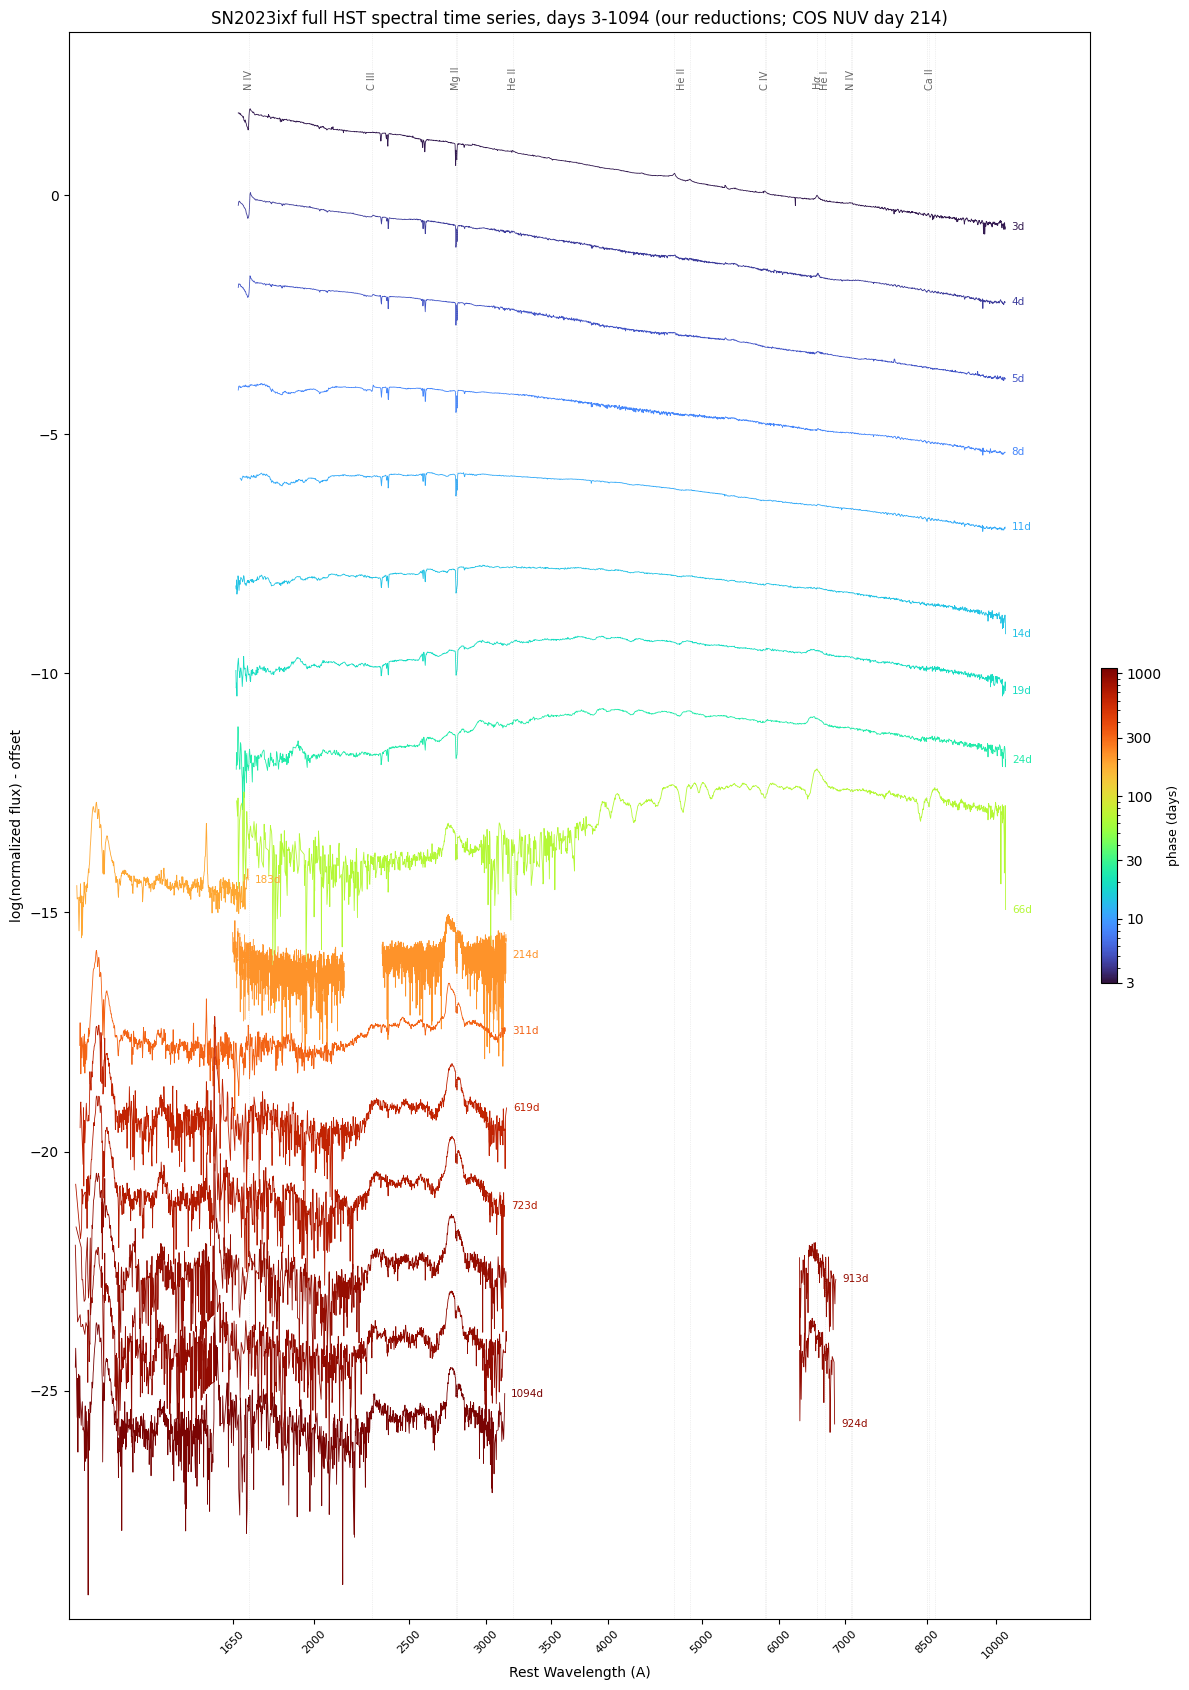

In [16]:
from matplotlib import cm, colors
import matplotlib as mpl

# load the COS NUV day-214 from the hasp cspec (NUVA+NUVB stripes, mask NUVC artifact zone)
cspec_path = glob(f'{hst}/hst_hasp_17497*/*_cspec.fits')
cspec_path = [p for p in cspec_path if 'lf88_cspec' in p][0]
hc = fits.getdata(cspec_path, 1)[0]
cw_raw, cf_raw, ceff = hc['WAVELENGTH'], hc['FLUX'], hc['EFF_EXPTIME']
# keep real coverage only; mask the 2150-2350 NUVC artifact
cos_mask = (ceff > 0) & np.isfinite(cf_raw) & (cw_raw > 1650) & (cw_raw < 3150) & \
           ~((cw_raw > 2150) & (cw_raw < 2350))
cw_cos, cf_cos = clean(cw_raw[cos_mask].astype(float), cf_raw[cos_mask].astype(float))

# full series: optical days 3-66 + late UV/red days 183-1094 + COS NUV day 214
series = [(float(e[0]), e[3], e[4]) for e in epochs] + \
         [(float(d), w, f) for d, w, f in late] + \
         [(214.0, cw_cos, cf_cos)]
series.sort(key=lambda s: s[0])

z = 0.000804   # M101 z
fig, ax = plt.subplots(figsize=(12, 17))
cnorm = colors.LogNorm(vmin=3, vmax=1100)
gap = 1.6
ally = []
for i, (day, w, f) in enumerate(series):
    w = w / (1 + z)
    y = np.log10(f / np.nanmedian(f)) - gap * i
    c = cm.turbo(cnorm(day))
    brk = np.where(np.diff(w) > 200)[0] + 1  # break lines across large wavelength gaps (UV->Ha)
    ax.plot(np.insert(w, brk, np.nan), np.insert(y, brk, np.nan), color=c, lw=0.6)
    fin = np.isfinite(y)
    # separate UV and Ha stub labels so they don't pile up on the same row
    segs = np.split(np.where(fin)[0], np.where(np.diff(np.where(fin)[0]) > 50)[0] + 1)
    for seg in segs:
        if len(seg) == 0: continue
        ax.text(w[seg[-1]] * 1.015, y[seg[-1]], f'{day:.0f}d', color=c, fontsize=7.5, va='center')
    ally.append(y[fin])

ally = np.concatenate(ally)
ytop = np.nanmax(ally) + 0.4
for lab, wls in lines:
    for wl in wls:
        ax.axvline(wl / (1 + z), color='0.7', ls=':', lw=0.5, alpha=0.4)
    ax.text(np.mean(wls) / (1 + z), ytop, lab, rotation=90, fontsize=7, color='0.4',
            va='bottom', ha='center')

ax.set_xscale('log')
ax.set_xticks(xticks); ax.set_xticklabels([str(t) for t in xticks], rotation=45, fontsize=8)
ax.minorticks_off()
ax.set_xlim(1120, 12500); ax.set_ylim(np.nanmin(ally) - 0.5, ytop + 1.2)
ax.set_xlabel('Rest Wavelength (A)'); ax.set_ylabel('log(normalized flux) - offset')
ax.set_title('SN2023ixf full HST spectral time series, days 3-1094 (our reductions; COS NUV day 214)')

# colorbar for the phase scale
sm = mpl.cm.ScalarMappable(cmap='turbo', norm=cnorm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.01, fraction=0.015)
cb.set_label('phase (days)', fontsize=9)
cb.set_ticks([3, 10, 30, 100, 300, 1000])
cb.set_ticklabels(['3', '10', '30', '100', '300', '1000'])

plt.tight_layout()
plt.savefig('../output/2023ixf_fullseries.png', dpi=130, bbox_inches='tight')
plt.show()
